# EDA & Preprocessing

## Libraries and Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
import warnings
import math
import os
import random
from pathlib import Path

## Load Data and Understanding

In [2]:
# # Locate dataset relative to the project root
# root = Path.cwd()
# if root.name == "notebooks":
#     root = root.parent

# # data_path = root / "datasetml_2026.csv"
# data_path = "data/datasetml_2026.csv"

# debug --- bentar
import os 
loc = os.getcwd()
root = os.path.dirname(loc)
data = os.path.join(root, "data")
# print(data)

df_train = pd.read_csv(os.path.join(data, "datasetml_2026.csv"))
df_train.shape


# df_train = pd.read_csv(data_path)

# df_train.shape

(10000, 12)

In [3]:
df_train.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [5]:
df_train.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


## Null and Duplicates Checking

In [6]:
# Cek missing values
df_train.isnull().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

In [7]:
# Cek duplicate rows
df_train.duplicated().sum()

np.int64(0)

## Seperate Target, Categorical, and Numerical

In [8]:
TARGET_COL = "placement_status"

CAT_COLS = [
    "college_tier",
    "country",
    "university_ranking_band",
    "specialization",
    "industry"
]

NUM_COLS = [
    "cgpa",
    "backlogs",
    "internship_count",
    "aptitude_score",
    "communication_score",
    "internship_quality_score"
]

train_copy = df_train.copy

## Data Visualization

Target Proportions (%):
placement_status
Placed        61.53
Not Placed    38.47
Name: proportion, dtype: float64


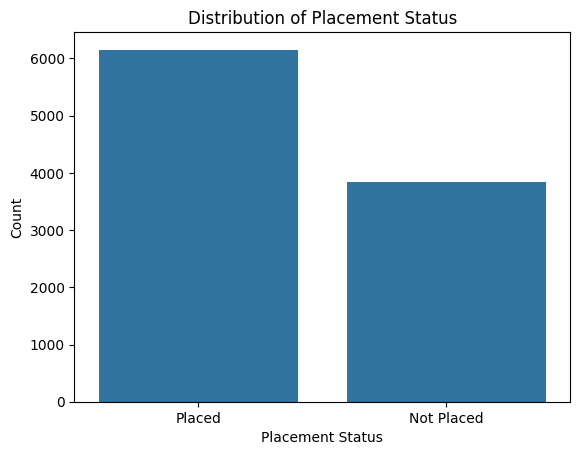

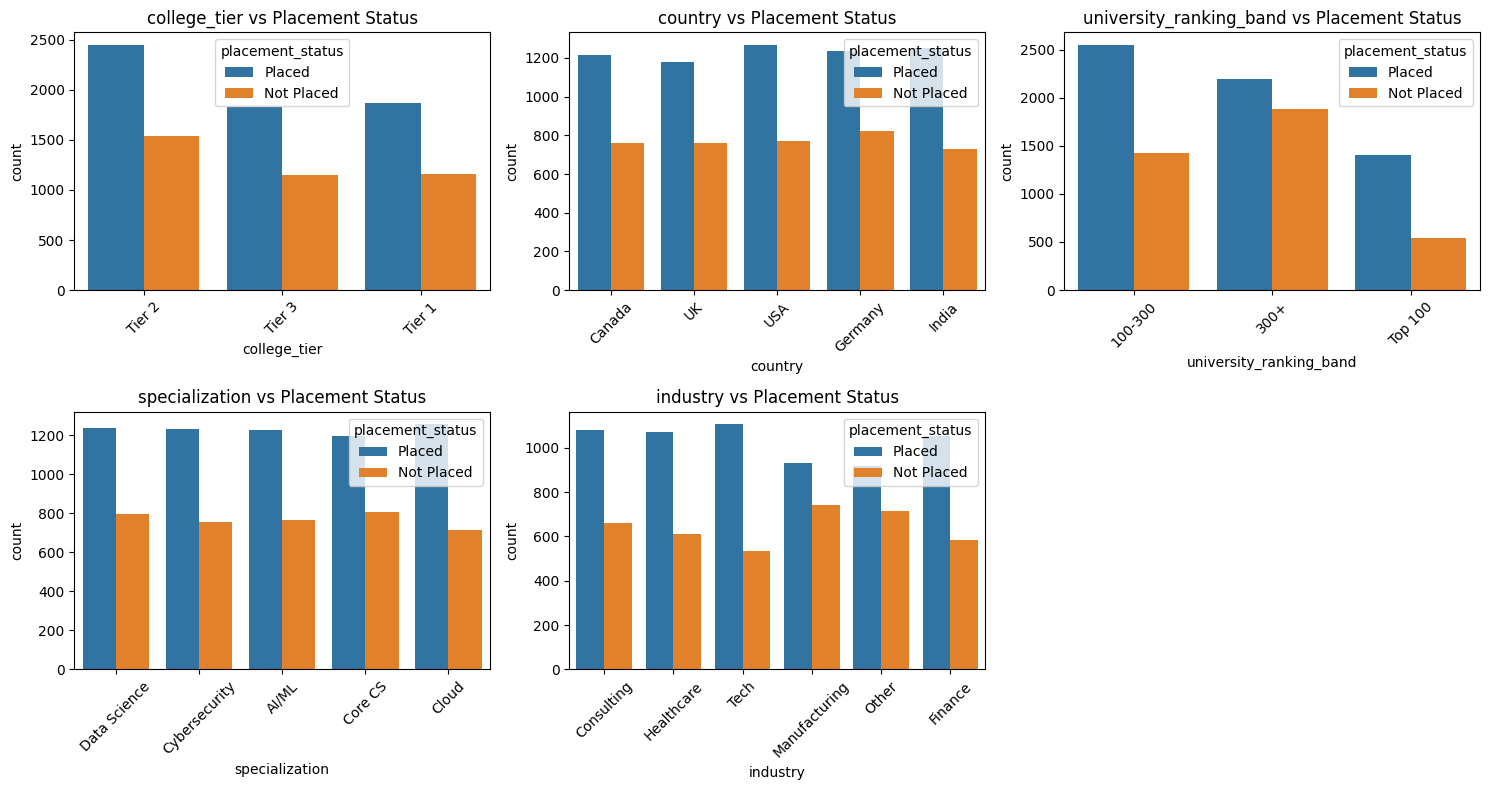

In [9]:
# check target distribution & proportions
proportions = df_train["placement_status"].value_counts(normalize=True) * 100
print("Target Proportions (%):")
print(proportions)

sns.countplot(data=df_train, x="placement_status")
plt.title("Distribution of Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.show()

# categorical features vs target
n = len(CAT_COLS)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    sns.countplot(data=df_train, x=col, hue="placement_status", ax=axes[i])
    axes[i].set_title(f"{col} vs Placement Status")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(CAT_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

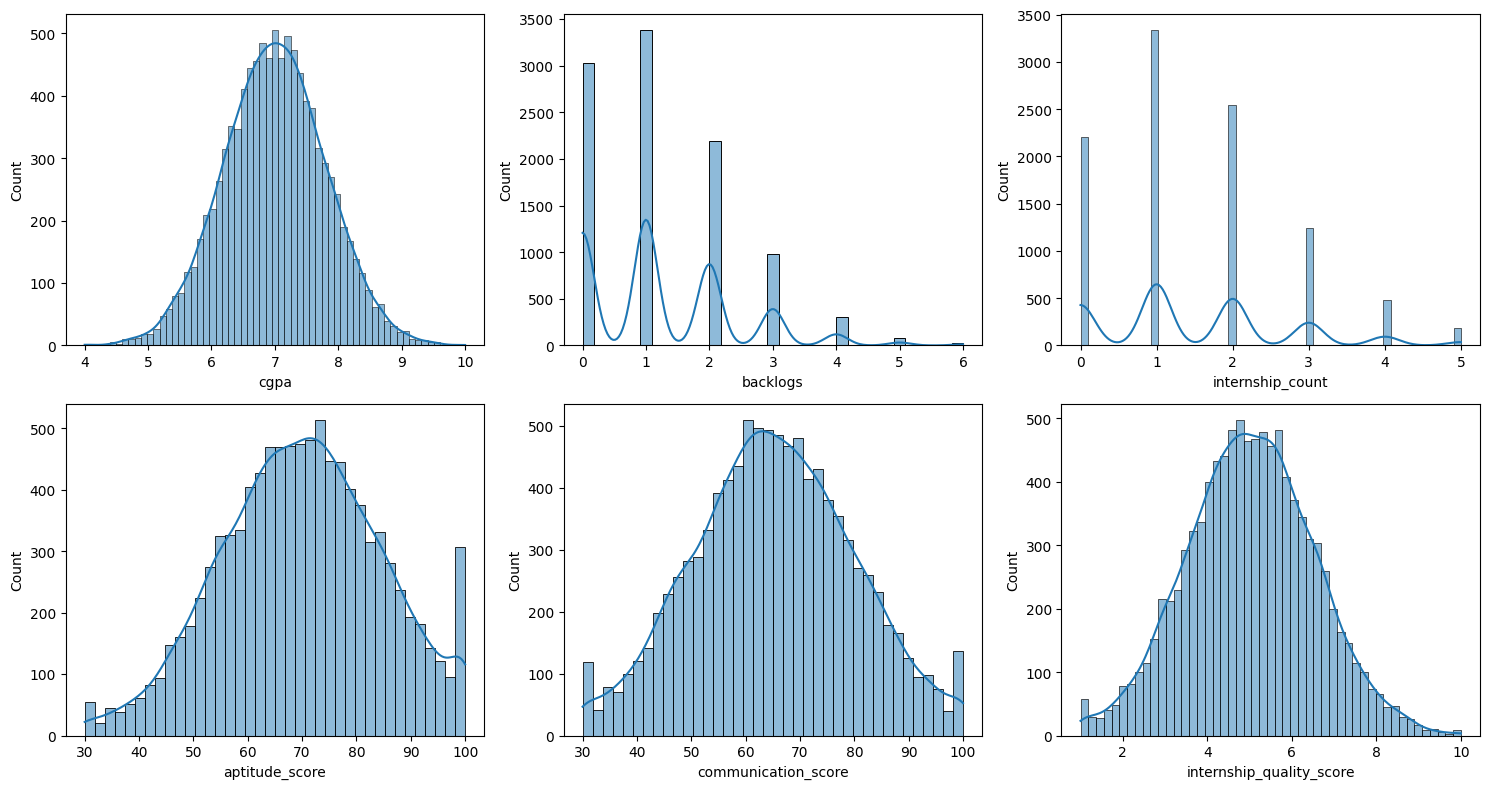

In [10]:
# numerical distribution
n = len(NUM_COLS)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.histplot(df_train[col], kde=True, ax=axes[i])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

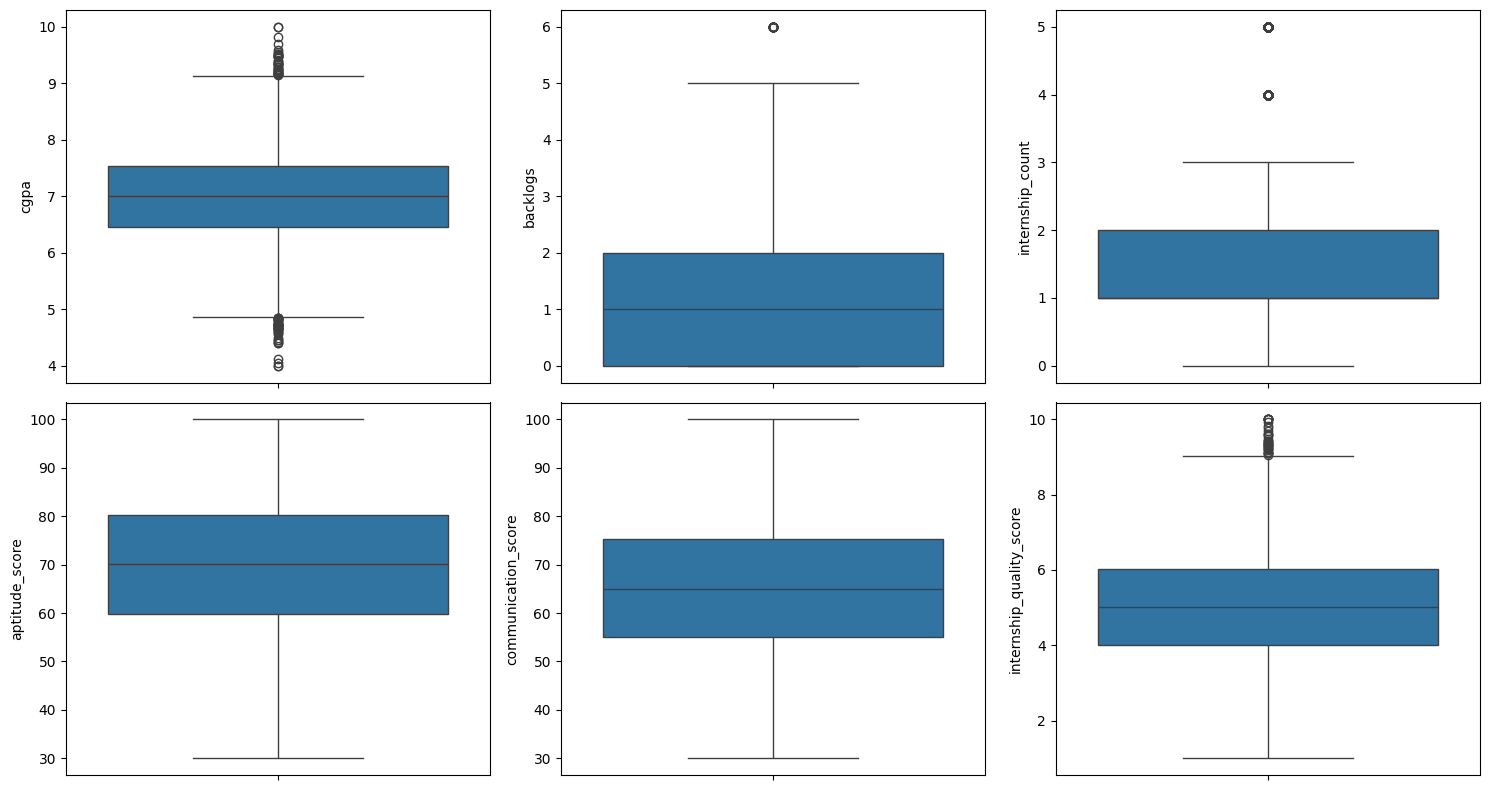

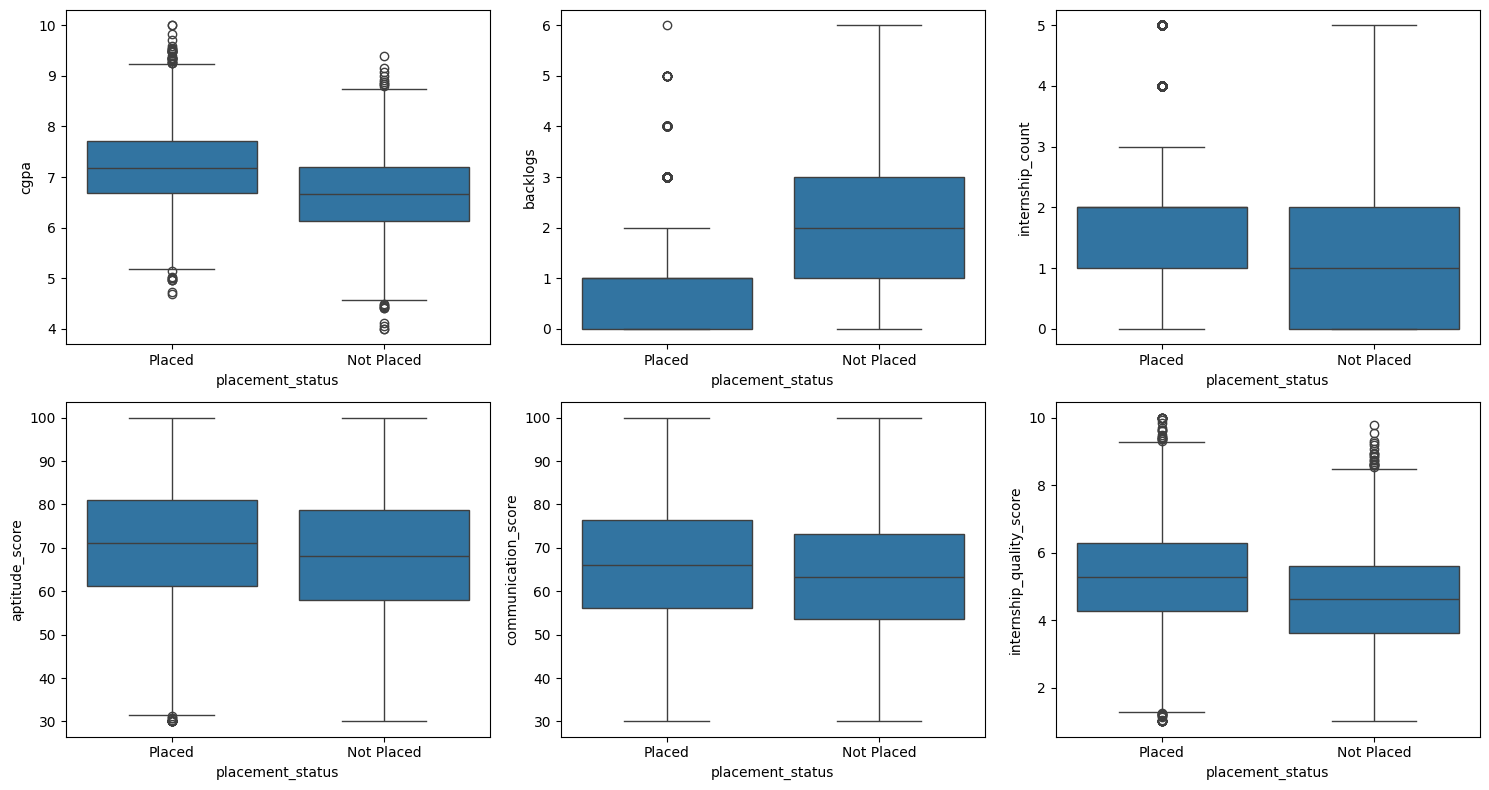

In [11]:
# numerical outliers
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=df_train, y=col, ax=axes[i])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# numerical vs target
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=df_train, x="placement_status", y=col, ax=axes[i])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Outlier Handling

In [12]:
# IQR
Q1 = df_train[NUM_COLS].quantile(0.25)
Q3 = df_train[NUM_COLS].quantile(0.75)
IQR = Q3 - Q1

# batas outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Check outlier on cols
outliers = ((df_train[NUM_COLS] < lower_bound) | (df_train[NUM_COLS] > upper_bound)).sum()
print("Jumlah outlier per kolom:")
print(outliers[outliers > 0])

Jumlah outlier per kolom:
cgpa                         83
backlogs                     29
internship_count            662
internship_quality_score     36
dtype: int64


In [13]:
# Delete baris yang mengandung outlier (Trimming)
df_train_cleaned = df_train[~((df_train[NUM_COLS] < lower_bound) | (df_train[NUM_COLS] > upper_bound)).any(axis=1)]

print(f"Ukuran data sebelum: {df_train.shape}")
print(f"Ukuran data setelah outlier dihapus: {df_train_cleaned.shape}")

# Update df_train untuk proses selanjutnya dan reset index
df_train = df_train_cleaned.copy().reset_index(drop=True)

Ukuran data sebelum: (10000, 12)
Ukuran data setelah outlier dihapus: (9195, 12)


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,9195.000000,9195.000000,9195.000000,9195.000000,9195.000000,9195.000000
mean,6.995659,1.236215,1.301468,69.908547,65.176672,5.006253
std,0.774121,1.123974,0.973006,14.718408,14.672364,1.483197
min,4.860346,0.000000,0.000000,30.000000,30.000000,1.000000
25%,6.469574,0.000000,1.000000,59.866846,55.164348,4.008964
50%,6.991718,1.000000,1.000000,70.165849,65.063069,5.002916
75%,7.527320,2.000000,2.000000,80.243458,75.253932,6.006653
max,9.133524,5.000000,3.000000,100.000000,100.000000,9.038546


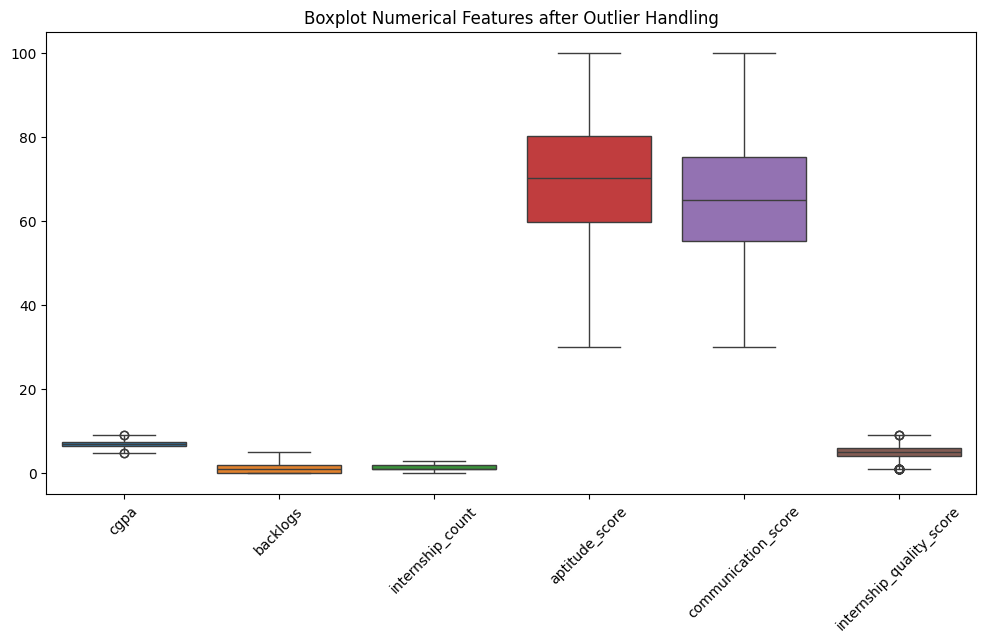

In [14]:
# Re-check statistics
display(df_train[NUM_COLS].describe())

# Visualisasi boxplot after cleaned
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train[NUM_COLS])
plt.xticks(rotation=45)
plt.title('Boxplot Numerical Features after Outlier Handling')
plt.show()

## Correlation Analysis

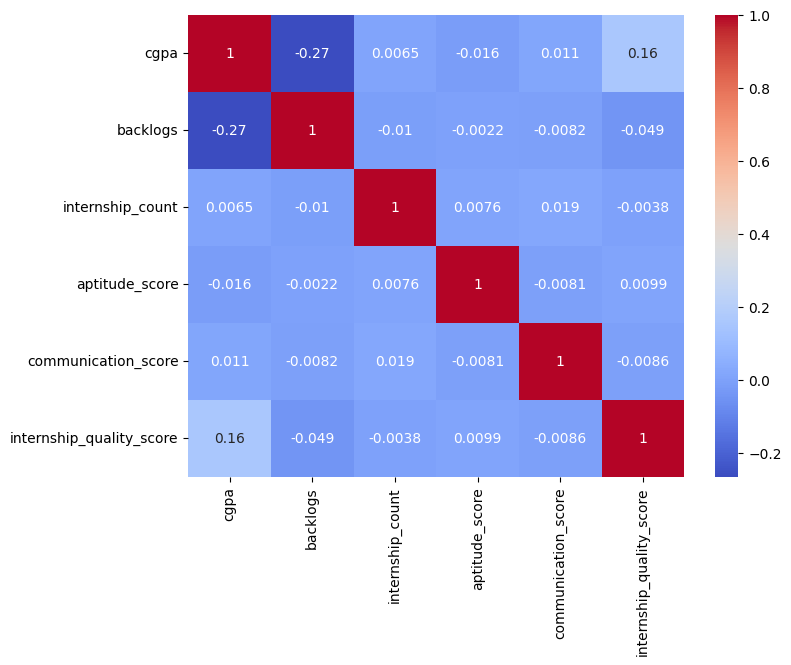

In [15]:
# correlation heatmap (numerical features only)
corr = df_train[NUM_COLS].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### Encoding Categorical Features

In [16]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(df_train[CAT_COLS])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(CAT_COLS))

df_train_processed = pd.concat([df_train.drop(columns=CAT_COLS), encoded_df], axis=1)

display(df_train_processed.head())

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,placement_status,college_tier_Tier 1,college_tier_Tier 2,college_tier_Tier 3,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,7.397371,1,2,53.57415,64.177062,5.481450,Placed,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,6.889389,0,1,60.68775,88.346052,4.625099,Placed,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,7.518151,0,2,64.56875,69.493171,5.227939,Placed,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,8.218424,0,3,73.46150,78.204854,5.150674,Placed,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6.812690,0,1,72.87643,72.102495,2.917127,Not Placed,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Scaling Numerical Features

In [17]:
scaler = StandardScaler()
df_train_processed[NUM_COLS] = scaler.fit_transform(df_train_processed[NUM_COLS])

display(df_train_processed.head())

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,placement_status,college_tier_Tier 1,college_tier_Tier 2,college_tier_Tier 3,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,0.518956,-0.210172,0.717950,-1.109854,-0.068132,0.320404,Placed,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.137286,-1.099921,-0.309849,-0.626515,1.579203,-0.256995,Placed,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.674986,-1.099921,0.717950,-0.362817,0.294208,0.149473,Placed,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.579639,-1.099921,1.745749,0.241408,0.887988,0.097377,Placed,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.236369,-1.099921,-0.309849,0.201655,0.472057,-1.408605,Not Placed,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Train-Test Split

In [18]:
# Convert target column to numerical if it's categorical
le = LabelEncoder()
df_train_processed[TARGET_COL] = le.fit_transform(df_train_processed[TARGET_COL])

X = df_train_processed.drop(columns=[TARGET_COL])
y = df_train_processed[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (7356, 28)
X_test shape: (1839, 28)
y_train shape: (7356,)
y_test shape: (1839,)


### Cross-Validation using K-Fold

In [19]:
# Model MLP sementara
model = MLPClassifier(random_state=42, max_iter=500)

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# list buat store metrics from each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("Starting KF CV...")

# tiap fold => train model, make prediction, calculate metrics
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    model.fit(X_train_fold, y_train_fold)

    y_pred_fold = model.predict(X_val_fold)

    accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
    precision_scores.append(precision_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))
    recall_scores.append(recall_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))
    f1_scores.append(f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))

    print(f"Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"Precision: {precision_scores[-1]:.4f}")
    print(f"Recall: {recall_scores[-1]:.4f}")
    print(f"F1-Score: {f1_scores[-1]:.4f}")

print("\n--- Average Cross-Validation Metrics ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

Starting KF CV...

--- Fold 1 ---


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.6933
Precision: 0.6929
Recall: 0.6933
F1-Score: 0.6931

--- Fold 2 ---


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.6922
Precision: 0.6884
Recall: 0.6922
F1-Score: 0.6866

--- Fold 3 ---


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.6949
Precision: 0.6935
Recall: 0.6949
F1-Score: 0.6942

--- Fold 4 ---


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.7009
Precision: 0.6979
Recall: 0.7009
F1-Score: 0.6984

--- Fold 5 ---
Accuracy: 0.7020
Precision: 0.6976
Recall: 0.7020
F1-Score: 0.6990

--- Average Cross-Validation Metrics ---
Average Accuracy: 0.6967 (+/- 0.0040)
Average Precision: 0.6941 (+/- 0.0035)
Average Recall: 0.6967 (+/- 0.0040)
Average F1-Score: 0.6943 (+/- 0.0045)


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### simpen di pickle


In [20]:
import pickle 
import os 

if not os.path.exists('models'): 
    os.makedirs('models')

processedData = { 
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test, 
    "le" : le
}

with open('models/processedData.pkl', 'wb') as f:
    pickle.dump(processedData, f)